# Fase 5. Descomposición de la desigualdad

**Tesis** · Desigualdades socioeconómicas, étnicas y territoriales en el bajo peso al nacer
en Colombia: análisis multinivel y predictivo de las estadísticas vitales, 1998-2024
**Autor** · Gregory Jesús Meléndez · **Director** · Lihki José Rubio Ortega
**Corresponde a** · Capítulo 4, Sección 4.4.5 del manuscrito

| | |
|---|---|
| **Entra** | `intermedios/muestra_armonizada.parquet` |
| **Sale** | cuatro tablas y dos figuras en `salidas/` |
| **Tiempo** | entre 3 y 6 minutos, casi todo en el bootstrap |

---

## Qué responde esta fase

**Qué proporción de la brecha socioeconómica es atribuible a cada determinante.** Es el
objetivo específico 4.

La Fase 3 entregó una cifra: cuánta desigualdad hay. No dice de dónde viene. Esta fase
reparte esa cifra entre los determinantes.

## Qué NO responde

No estima efectos causales. Una contribución elevada no significa que el determinante
*cause* esa parte de la desigualdad; significa que el producto de su asociación con el
desenlace por lo desigual que está repartido da esa cantidad. La estimación de efectos
ajustados es la Fase 4, y las dos fases pueden ordenar los determinantes de forma distinta
sin contradecirse.

## La identidad, que es todo el método

Si el desenlace admite la representación lineal $y_i = \alpha + \sum_k \beta_k x_{ki} +
\varepsilon_i$, el índice de concentración se descompone de forma exacta:

$$CI \;=\; \sum_k \underbrace{\left(\frac{\beta_k \bar{x}_k}{\mu}\right)}_{\text{elasticidad}}
\cdot \underbrace{CI_k}_{\substack{\text{índice de concentración}\\ \text{del determinante}}}
\;+\; \frac{GCI_\varepsilon}{\mu}$$

Conviene tener presente la lectura de esa identidad **antes** de mirar ninguna cifra:

> Un determinante contribuye a la desigualdad solo si cumple **las dos condiciones a la
> vez**: afectar al desenlace y estar desigualmente repartido en la población.

Un factor de riesgo potentísimo distribuido por igual entre todos los estratos no genera
desigualdad: genera enfermedad. Y un factor muy desigualmente repartido que no afecte al
desenlace tampoco contribuye. Lo que se reparte es el **producto** de los dos.

De ahí que esta fase pueda dar resultados que parezcan contradecir a la Fase 4. No la
contradicen: responden a otra pregunta.

## Por qué un modelo lineal y no el logístico de la Fase 4

La identidad es exacta solo si el modelo es lineal en los parámetros. Con un logístico, la
suma de las contribuciones no reproduce el índice y el residuo deja de tener interpretación:
absorbe a la vez la parte no explicada y el error de aproximación, sin que pueda saberse
cuánta es cada cosa.

Wagstaff, van Doorslaer y Watanabe (2003) contemplan las dos vías. Aquí se usa el **modelo
lineal de probabilidad** por tres razones:

1. La identidad se cumple de forma exacta, de modo que el residuo mide lo que dice medir.
2. Todas las covariables son categóricas y entran como indicadoras, de manera que la
   linealidad no impone forma funcional alguna sobre variables que no la tienen.
3. La objeción habitual al modelo lineal de probabilidad —que puede predecir fuera de
   $[0,1]$— no aplica: aquí no se predice nada, se reparte una cantidad ya calculada.

Quien reproduzca este análisis debe correr antes `01b_armonizacion.ipynb` y
`03_desigualdad.ipynb`.

## 0. Entorno

**Qué hacemos.** Importamos `src/descomposicion.py`, que implementa la identidad anterior, y
`src/desigualdad.py`, del que se reutiliza el rango fraccional para que el eje socioeconómico
sea exactamente el mismo que el de la Fase 3.

**Por qué importa que sea el mismo.** Si el rango se calculara aquí de otra forma, el índice
que se reparte no sería el que se reportó en la Fase 3 y las dos secciones del manuscrito
darían cifras distintas para la misma cantidad.

In [1]:
# ---------------------------------------------------------------------------
# Entorno
# ---------------------------------------------------------------------------

import sys
from pathlib import Path

def _encontrar_raiz(inicio: Path) -> Path:
    """Sube por el arbol hasta encontrar src/config.py."""
    for candidata in [inicio, *inicio.parents]:
        if (candidata / "src" / "config.py").exists():
            return candidata
    raise FileNotFoundError(f"No encuentro src/config.py subiendo desde {inicio}")

RAIZ = _encontrar_raiz(Path.cwd())
sys.path.insert(0, str(RAIZ / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import SEMILLA, DIR_TABLAS
from datos import leer_intermedio
from util import cronometro, guardar_tabla
from graficos import estilo, guardar_figura
import descomposicion

estilo()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)

# --- Sello de version ------------------------------------------------------
# VS Code conserva el estado no guardado de cada editor y lo restaura al
# recargar la ventana, de modo que una pestana puede seguir ejecutando una
# version anterior del notebook sin que nada lo delate.
VERSION = "59ed330c"
print(f"version en memoria: {VERSION}")
try:
    import hashlib, json as _json
    _c = _json.load(open(RAIZ / "notebooks" / "05_descomposicion.ipynb",
                         encoding="utf-8"))["cells"]
    _t = "\n".join("".join(c["source"]) for c in _c).replace(VERSION, "")
    _d = hashlib.sha1(_t.encode("utf-8")).hexdigest()[:8]
    print(f"version en disco  : {_d}")
    print("COINCIDEN" if _d == VERSION else
          "\n" + "!"*60 + "\nNO COINCIDEN: la pestana esta desactualizada.\n"
          "Ctrl+Shift+P -> 'File: Revert File'. No interpretes esta corrida.\n" + "!"*60)
except FileNotFoundError:
    print("(archivo en disco no encontrado)")

# --- Carga -----------------------------------------------------------------
# Solo las columnas que esta fase usa. El parquet es columnar: leer nueve de
# veinticinco es la diferencia entre unos segundos y un minuto largo.
COLUMNAS = ["ANIO", "BPN", "EDUC4_MADRE", "ESTCIV5", "SEG4", "SEGORD3",
            "AREA_RES", "EDAD_MADRE", "N_HIJOSV", "MUL_PARTO"]

with cronometro("lectura de la muestra armonizada"):
    muestra = leer_intermedio("muestra_armonizada", columnas=COLUMNAS)

print(f"\nmuestra: {len(muestra):,} registros")
for v in ["EDUC4_MADRE", "ESTCIV5", "SEG4", "AREA_RES"]:
    print(f"  {v:<14} informado en {muestra[v].notna().mean()*100:6.2f} %")

version en memoria: 59ed330c
version en disco  : 59ed330c
COINCIDEN
[inicio] lectura de la muestra armonizada
[fin]    lectura de la muestra armonizada  ->  1.2 s

muestra: 17,376,860 registros
  EDUC4_MADRE    informado en  96.80 %
  ESTCIV5        informado en  97.79 %
  SEG4           informado en  97.38 %
  AREA_RES       informado en  99.21 %


**Cómo se lee esta salida.**

Debe decir **17.376.860** registros. `EDUC4_MADRE` ronda el 96,8 % de informado y `SEG4` el
97,4 %, las mismas cifras que imprime la Fase 3: si no coinciden, se está leyendo otro
archivo o el intermedio se regeneró con otro filtro, y hay que resolverlo antes de seguir.

Si aparece `FileNotFoundError: muestra_armonizada`, falta correr `01b_armonizacion.ipynb`.

## 1. Las covariables demográficas

**Qué hacemos.** Construimos `EDAD3`, `PARIDAD4` y `MULTIPLE3` exactamente igual que en la
Fase 4.

**Por qué se construyen aquí otra vez y no se leen de un intermedio.** Porque son
derivaciones de tres líneas y guardarlas crearía una dependencia de ejecución entre
notebooks que el proyecto evita a propósito: cada notebook debe poder correrse solo. Lo que
sí es obligatorio es que las reglas sean **idénticas** a las de la Fase 4; si divergieran, la
Fase 5 estaría descomponiendo una población distinta de la que la Fase 4 modeló.

**Por qué entran en la descomposición.** La edad materna, la paridad y la multiplicidad
afectan al peso al nacer por vía biológica y no se reparten por igual entre estratos
sociales: las madres adolescentes tienen, por construcción, menos educación completada. Si
se dejaran fuera, su contribución se repartiría entre los determinantes sociales y estos
aparecerían con una contribución inflada.

In [2]:
# ---------------------------------------------------------------------------
# Covariables demograficas, con las MISMAS reglas que la Fase 4
# ---------------------------------------------------------------------------

# --- Edad materna: nueve bandas quinquenales -> tres tramos obstetricos ----
# Los codigos van de 1 (10-14 anios) a 9 (50-54). El tramo de menor riesgo es
# 20-34, que corresponde a los codigos 3 a 5.
edad = pd.to_numeric(muestra["EDAD_MADRE"], errors="coerce")
muestra["EDAD3"] = pd.Categorical(
    np.select([edad <= 2, (edad >= 3) & (edad <= 5), edad >= 6],
              ["menor de 20", "20 a 34", "35 o mas"], default=None),
    categories=["20 a 34", "menor de 20", "35 o mas"])

# --- Paridad: numero de hijos nacidos vivos, incluido el actual ------------
hijos = pd.to_numeric(muestra["N_HIJOSV"], errors="coerce")
muestra["PARIDAD4"] = pd.Categorical(
    np.select([hijos == 1, hijos == 2, hijos == 3, hijos >= 4],
              ["1 hijo", "2 hijos", "3 hijos", "4 o mas"], default=None),
    categories=["1 hijo", "2 hijos", "3 hijos", "4 o mas"])

# --- Multiplicidad ---------------------------------------------------------
# Triple y cuadruple suman poco mas de siete mil nacimientos en toda la serie:
# separarlos daria celdas vacias en muchas combinaciones.
mult = pd.to_numeric(muestra["MUL_PARTO"], errors="coerce")
muestra["MULTIPLE3"] = pd.Categorical(
    np.select([mult == 1, mult == 2, mult >= 3],
              ["simple", "doble", "triple o mas"], default=None),
    categories=["simple", "doble", "triple o mas"])

print("COVARIABLES DEMOGRAFICAS\n")
for var in ["EDAD3", "PARIDAD4", "MULTIPLE3"]:
    print(f"{var}   ({muestra[var].notna().mean()*100:.2f} % informado)")
    for k, n in muestra[var].value_counts().sort_index().items():
        print(f"    {str(k):<14} {n:>12,}  {n/len(muestra)*100:5.2f} %")
    print()

COVARIABLES DEMOGRAFICAS

EDAD3   (99.80 % informado)
    20 a 34          11,794,738  67.88 %
    menor de 20       3,717,626  21.39 %
    35 o mas          1,829,082  10.53 %

PARIDAD4   (99.27 % informado)
    1 hijo            7,615,450  43.83 %
    2 hijos           5,298,773  30.49 %
    3 hijos           2,473,760  14.24 %
    4 o mas           1,862,645  10.72 %

MULTIPLE3   (99.31 % informado)
    simple           16,945,108  97.52 %
    doble               304,200   1.75 %
    triple o mas          7,520   0.04 %



**Cómo se lee esta salida.**

Los porcentajes de informado deben coincidir con los de la Fase 4. La distribución esperable:
en `PARIDAD4`, algo más del 43 % en «1 hijo»; en `MULTIPLE3`, más del 97 % en «simple».

Una proporción de «triple o mas» por encima del 0,1 % indicaría que el campo `MUL_PARTO`
arrastra códigos centinela sin convertir a nulo, y habría que volver a la Fase 1 antes de
seguir.

## 2. La descomposición principal

**Qué hacemos.** Repartimos el índice de concentración del bajo peso al nacer, ordenado por
nivel educativo materno, entre siete determinantes: los cuatro sociales y los tres
demográficos.

**Las referencias.** Son las mismas que en la Fase 4, y por el mismo motivo: en los
determinantes sociales se omite la primera categoría; en las covariables demográficas se fija
explícitamente el grupo de menor riesgo obstétrico. Conviene recordar la implicación al leer
la tabla: **la contribución de una categoría es la de estar en ella en lugar de en la
referencia**. El total por variable, en cambio, no depende de cuál sea la referencia, y es la
cifra comparable entre determinantes.

**Sobre el tiempo de cómputo.** Todas las covariables son categóricas, de modo que los
diecisiete millones de registros se reducen a unos miles de combinaciones distintas. Los
mínimos cuadrados ponderados sobre esas celdas dan exactamente los mismos coeficientes que
sobre los registros individuales: no es una aproximación, es la misma suma reagrupada.

In [3]:
# ---------------------------------------------------------------------------
# Descomposicion principal
# ---------------------------------------------------------------------------

SOCIALES = ["EDUC4_MADRE", "ESTCIV5", "SEG4", "AREA_RES"]
DEMOGRAFICAS = ["EDAD3", "PARIDAD4", "MULTIPLE3"]
DETERMINANTES = SOCIALES + DEMOGRAFICAS

# Las mismas referencias que la Fase 4. En los sociales, la primera categoria;
# en las demograficas, el grupo de menor riesgo obstetrico fijado a mano.
REFERENCIAS = {
    "EDAD3": "20 a 34",
    "PARIDAD4": "1 hijo",
    "MULTIPLE3": "simple",
}

with cronometro("descomposicion sobre la muestra completa"):
    tabla, resumen = descomposicion.descomponer(
        muestra, orden="EDUC4_MADRE", variables=DETERMINANTES,
        referencias=REFERENCIAS)

print("RESUMEN\n")
print(f"  registros usados        {resumen['n']:>14,}")
print(f"  celdas distintas        {resumen['celdas']:>14,}")
print(f"  prevalencia global      {resumen['prevalencia_global']*100:>13.4f} %")
print(f"  indice de concentracion {resumen['ci']:>14.6f}")
print(f"  correccion de Erreygers {resumen['erreygers']:>14.6f}")
print(f"  suma de contribuciones  {resumen['suma_contribuciones']:>14.6f}")
print(f"  residuo                 {resumen['residuo']:>14.6f}"
      f"   ({resumen['residuo_pct']:.2f} % del total)")

print("\n\nCONTRIBUCION POR VARIABLE (lo comparable entre determinantes)\n")
totales = (tabla[tabla["categoria"] == "TOTAL de la variable"]
           .sort_values("contribucion", key=abs, ascending=False))
print(totales[["variable", "contribucion", "pct_del_total"]]
      .to_string(index=False))

[inicio] descomposicion sobre la muestra completa
[fin]    descomposicion sobre la muestra completa  ->  4.6 s
RESUMEN

  registros usados            15,946,216
  celdas distintas                 4,698
  prevalencia global             8.7666 %
  indice de concentracion       0.018182
  correccion de Erreygers       0.006376
  suma de contribuciones        0.018182
  residuo                      -0.000000   (-0.00 % del total)


CONTRIBUCION POR VARIABLE (lo comparable entre determinantes)

   variable  contribucion  pct_del_total
   PARIDAD4      0.015289      84.089974
       SEG4      0.006955      38.253252
    ESTCIV5     -0.004473     -24.600604
   AREA_RES      0.004096      22.526674
EDUC4_MADRE     -0.003425     -18.837276
      EDAD3     -0.001143      -6.285388
  MULTIPLE3      0.000882       4.853367


**Cómo se lee esta salida, y una advertencia que condiciona todo lo demás.**

El **residuo va a salir cero**, y no es un acierto del modelo: es una identidad algebraica.
El bloque 3 lo demuestra. Anticipándolo aquí para que no se lea mal:

> El rango fraccional es constante dentro de cada nivel educativo, de modo que es una
> combinación lineal exacta de las indicadoras de `EDUC4_MADRE`. Los residuos de mínimos
> cuadrados son ortogonales a los regresores y, por tanto, a cualquier combinación lineal
> suya. Si `EDUC4_MADRE` está entre los regresores, la covarianza entre el residuo y el rango
> es cero **por construcción**.

**Consecuencia para la interpretación.** El «porcentaje explicado» es del 100 % siempre y no
mide en absoluto la bondad del reparto. Presentarlo como evidencia de que el modelo explica
la desigualdad sería un error, y de los que un jurado detecta. Lo informativo es el **reparto
relativo** entre determinantes.

**Cómo se leen los signos.** Una contribución del mismo signo que el índice total empuja la
desigualdad en la dirección observada; una de signo contrario la contrarresta. Dado que el
índice del período completo es positivo —el desenlace se concentra en el extremo más
educado—, un determinante con contribución negativa está tirando en la dirección clásica del
gradiente social.

**Correspondencia con el manuscrito.** La tabla de totales por variable alimenta la Sección
5.5.1.

## 3. Por qué el residuo es cero: la comprobación

**Qué hacemos.** Repetimos la descomposición **sin** la educación entre los regresores y
comparamos el residuo con el del bloque anterior.

**Por qué merece un bloque propio.** Porque es la diferencia entre reportar un «100 %
explicado» que no significa nada y entender qué reparte realmente la descomposición. Y
porque la versión sin educación responde a una pregunta con contenido propio: **cuánta
desigualdad educativa queda sin explicar por los demás determinantes**, que es una medida de
hasta qué punto la educación opera por vías distintas de las recogidas en el modelo.

In [4]:
# ---------------------------------------------------------------------------
# El residuo es cero por construccion: demostracion empirica
# ---------------------------------------------------------------------------

# Misma muestra, mismo ordenamiento, mismos determinantes MENOS la educacion.
SIN_EDUCACION = [v for v in DETERMINANTES if v != "EDUC4_MADRE"]

with cronometro("descomposicion sin la educacion entre los regresores"):
    tabla_sin, resumen_sin = descomposicion.descomponer(
        muestra, orden="EDUC4_MADRE", variables=SIN_EDUCACION,
        referencias=REFERENCIAS)

comparacion = pd.DataFrame([
    {"especificacion": "con EDUC4_MADRE entre los regresores",
     "ci": resumen["ci"],
     "suma_contribuciones": resumen["suma_contribuciones"],
     "residuo": resumen["residuo"],
     "residuo_pct": resumen["residuo_pct"]},
    {"especificacion": "sin EDUC4_MADRE entre los regresores",
     "ci": resumen_sin["ci"],
     "suma_contribuciones": resumen_sin["suma_contribuciones"],
     "residuo": resumen_sin["residuo"],
     "residuo_pct": resumen_sin["residuo_pct"]},
])

print("EFECTO DE INCLUIR EL ORDENAMIENTO ENTRE LOS REGRESORES\n")
print(comparacion.to_string(index=False))

# El indice total es el MISMO en las dos filas: no depende del modelo, solo de
# como se reparte el desenlace a lo largo del rango. Lo que cambia es el
# reparto.
print(f"\nel indice total coincide en ambas: "
      f"{np.isclose(resumen['ci'], resumen_sin['ci'])}")

guardar_tabla(comparacion, "descomposicion_residuo_cero", decimales=6)

print("\n\nCONTRIBUCIONES SIN LA EDUCACION (esta version si tiene residuo)\n")
tot_sin = (tabla_sin[tabla_sin["categoria"] == "TOTAL de la variable"]
           .sort_values("contribucion", key=abs, ascending=False))
print(pd.concat([tot_sin,
                 tabla_sin[tabla_sin["variable"] == "RESIDUO"]])
      [["variable", "contribucion", "pct_del_total"]].to_string(index=False))

[inicio] descomposicion sin la educacion entre los regresores
[fin]    descomposicion sin la educacion entre los regresores  ->  4.2 s
EFECTO DE INCLUIR EL ORDENAMIENTO ENTRE LOS REGRESORES

                      especificacion       ci  suma_contribuciones       residuo   residuo_pct
con EDUC4_MADRE entre los regresores 0.018182             0.018182 -1.630640e-16 -8.968495e-13
sin EDUC4_MADRE entre los regresores 0.018182             0.020385 -2.202979e-03 -1.211635e+01

el indice total coincide en ambas: True
tabla guardada: descomposicion_residuo_cero.csv y descomposicion_residuo_cero.tex


CONTRIBUCIONES SIN LA EDUCACION (esta version si tiene residuo)

 variable  contribucion  pct_del_total
 PARIDAD4      0.014921      82.065263
     SEG4      0.006452      35.484599
  ESTCIV5     -0.004608     -25.344237
 AREA_RES      0.003981      21.893715
    EDAD3     -0.001243      -6.835396
MULTIPLE3      0.000882       4.852409
  RESIDUO     -0.002203     -12.116352


**Cómo se lee esta salida.**

La primera fila debe mostrar un residuo del orden de $10^{-16}$ —cero hasta precisión de
máquina— y la segunda, un residuo que absorbe la mayor parte del índice.

El índice total tiene que ser **idéntico** en las dos filas, y el `True` lo confirma. Es la
comprobación de que lo que cambia es el reparto y no la cantidad repartida: el índice de
concentración es una propiedad de los datos, no del modelo.

Si el índice difiriera entre las dos filas, habría un error en el cálculo del rango
fraccional, porque es lo único que las dos comparten.

**Lo que aporta la segunda especificación.** Su residuo mide cuánta desigualdad educativa no
pasa por el estado conyugal, el aseguramiento, el área de residencia ni la composición
demográfica. Un residuo alto ahí significa que la educación opera por mecanismos que el
certificado de nacido vivo no registra —nutrición, exposición laboral, calidad efectiva de la
atención recibida— y es un argumento para la sección de limitaciones.

**Correspondencia con el manuscrito.** Este bloque sostiene la nota metodológica de la
Sección 4.4.5 y la advertencia de la Sección 5.5.1.

## 4. Los dos componentes de cada contribución

**Qué hacemos.** Separamos cada contribución en sus dos factores: la **elasticidad** y el
**índice de concentración del propio determinante**.

**Por qué esto es lo más informativo de la fase.** La contribución es un producto, y dos
determinantes pueden llegar al mismo valor por caminos opuestos:

| | Elasticidad | $CI_k$ | Lectura |
|---|---|---|---|
| **A** | alta | bajo | factor de riesgo potente, pero repartido por igual |
| **B** | baja | alto | factor débil, pero concentrado en un extremo |

Y la implicación de política es distinta en cada caso. Sobre **A** se actúa reduciendo la
exposición en toda la población; sobre **B**, redistribuyéndola. Reportar solo el producto
oculta esa diferencia, que es justamente la que interesa a quien tiene que decidir dónde
intervenir.

In [5]:
# ---------------------------------------------------------------------------
# Elasticidad y concentracion de cada determinante, por separado
# ---------------------------------------------------------------------------

# Se filtra con una sola mascara. POR QUE: encadenar dos filtros booleanos
# calculados sobre el marco ORIGINAL desalinea los indices y pandas avisa o,
# peor, devuelve filas equivocadas en silencio.
es_categoria = ((tabla["categoria"] != "TOTAL de la variable")
                & (tabla["variable"] != "RESIDUO"))
componentes = (tabla.loc[es_categoria]
               .copy()
               .sort_values("contribucion", key=abs, ascending=False))

# Se renombran las columnas a lo que significan, para que la tabla del
# manuscrito no exija consultar el codigo.
componentes = componentes.rename(columns={
    "prevalencia_exposicion": "expuestos",
    "elasticidad": "elasticidad",
    "ci_determinante": "ci_del_determinante",
})

print("LOS DOS COMPONENTES DE CADA CONTRIBUCION\n")
print(componentes[["variable", "categoria", "expuestos", "elasticidad",
                   "ci_del_determinante", "contribucion", "pct_del_total"]]
      .to_string(index=False))

guardar_tabla(componentes, "descomposicion_componentes", decimales=6)
guardar_tabla(totales.reset_index(drop=True),
              "descomposicion_por_variable", decimales=6)

LOS DOS COMPONENTES DE CADA CONTRIBUCION

   variable    categoria  expuestos  elasticidad  ci_del_determinante  contribucion  pct_del_total
EDUC4_MADRE            3   0.192951    -0.027748             0.807049     -0.022394    -123.168310
EDUC4_MADRE            1   0.202961    -0.027272            -0.764973      0.020862     114.741682
   PARIDAD4      4 o mas   0.104965    -0.034128            -0.408721      0.013949      76.717322
       SEG4            3   0.448211    -0.026504            -0.167737      0.004446      24.450909
   PARIDAD4      3 hijos   0.142702    -0.034414            -0.127331      0.004382      24.100614
    ESTCIV5            2   0.654728     0.064405            -0.050759     -0.003269     -17.980253
   PARIDAD4      2 hijos   0.310092    -0.062928             0.048333     -0.003041     -16.727962
       SEG4            4   0.144474    -0.011819            -0.240183      0.002839      15.613083
   AREA_RES            2   0.075249    -0.010214            -0.2447

**Cómo se lee esta salida.**

- **`expuestos`** es la proporción de la población en esa categoría. Una categoría con muy
  pocos expuestos difícilmente contribuye mucho, por grande que sea su efecto.
- **`elasticidad`** es el cambio relativo en la prevalencia global atribuible a esa
  categoría. Su signo es el del coeficiente: negativo significa menos riesgo que la
  referencia.
- **`ci_del_determinante`** dice cómo se reparte la exposición a lo largo del gradiente
  educativo. Negativo: se concentra en la parte baja. Positivo: en la alta. **Cercano a cero
  es la observación interesante**, porque significa que esa exposición no es socialmente
  desigual, y entonces su contribución será pequeña aunque su efecto sea grande.
- **`contribucion`** es el producto de las dos anteriores.

Una comprobación de coherencia: las categorías de `MULTIPLE3` deberían tener un
`ci_del_determinante` próximo a cero. La Fase 1 estableció que la multiplicidad se asocia con
el desenlace ($V = 0{,}2419$) pero casi nada con la educación ($V = 0{,}0106$), de modo que su
contribución debe ser pequeña pese a ser un factor de riesgo potente. Si saliera una
contribución grande, habría una inconsistencia entre las dos fases que resolver.

**Correspondencia con el manuscrito.** Esta tabla es la Sección 5.5.2.

## 5. Intervalos de confianza

**Qué hacemos.** Calculamos el intervalo del 95 % de cada contribución por bootstrap.

**Por qué paramétrico y no remuestreo de individuos.** Remuestrear diecisiete millones de
filas quinientas veces es inviable en un portátil. Como el desenlace es binario y dentro de
cada celda todos los registros comparten covariables, el número de casos de una celda se
distribuye $\text{Binomial}(n_c, p_c)$. Se simula ese conteo y se rehace la descomposición.

Es **el mismo procedimiento que la Fase 3** aplica al índice de concentración, de modo que
los intervalos de las dos fases son comparables entre sí.

**Lo que este intervalo no recoge, y conviene declararlo.** La incertidumbre sobre el
*tamaño* de cada celda, que se trata como fijo. Es la práctica habitual con registros
administrativos, donde la población no es una muestra de nada, pero dejarlo implícito sería
ocultar un supuesto.

In [6]:
# ---------------------------------------------------------------------------
# Bootstrap parametrico sobre las celdas
# ---------------------------------------------------------------------------

N_REPLICAS = 500   # 500 basta para percentiles del 2,5 y el 97,5 %

with cronometro(f"bootstrap de {N_REPLICAS} replicas"):
    ic = descomposicion.bootstrap(
        muestra, orden="EDUC4_MADRE", variables=DETERMINANTES,
        referencias=REFERENCIAS, n_replicas=N_REPLICAS, semilla=SEMILLA)

# Se une al resultado puntual para poder leer estimacion e intervalo juntos.
con_ic = tabla.merge(ic, on=["variable", "categoria"], how="left")

# Marca de si el intervalo incluye el cero: una contribucion cuyo intervalo
# cruza el cero no permite afirmar ni siquiera su direccion.
con_ic["cruza_cero"] = np.where(
    con_ic["ic_inf"].notna() & (con_ic["ic_inf"] * con_ic["ic_sup"] < 0),
    "SI", "")

print("CONTRIBUCION POR VARIABLE, CON INTERVALO DEL 95 %\n")
vista = con_ic[con_ic["categoria"] == "TOTAL de la variable"].copy()
vista = vista.sort_values("contribucion", key=abs, ascending=False)
print(vista[["variable", "contribucion", "ic_inf", "ic_sup", "cruza_cero"]]
      .to_string(index=False))

guardar_tabla(con_ic, "descomposicion_con_intervalos", decimales=6)

[inicio] bootstrap de 500 replicas
[fin]    bootstrap de 500 replicas  ->  34.5 s
CONTRIBUCION POR VARIABLE, CON INTERVALO DEL 95 %

   variable  contribucion    ic_inf    ic_sup cruza_cero
   PARIDAD4      0.015289  0.015014  0.015600           
       SEG4      0.006955  0.006579  0.007385           
    ESTCIV5     -0.004473 -0.004626 -0.004318           
   AREA_RES      0.004096  0.003867  0.004337           
EDUC4_MADRE     -0.003425 -0.004372 -0.002529           
      EDAD3     -0.001143 -0.001276 -0.000983           
  MULTIPLE3      0.000882  0.000879  0.000886           
tabla guardada: descomposicion_con_intervalos.csv y descomposicion_con_intervalos.tex


**Cómo se lee esta salida.**

La columna `cruza_cero` es la que hay que mirar primero. Una contribución cuyo intervalo
incluye el cero no permite afirmar ni siquiera en qué dirección empuja ese determinante, y
debe reportarse como tal en lugar de citar el valor puntual.

Con diecisiete millones de registros, lo esperable es que casi ningún intervalo cruce el
cero: los intervalos serán estrechos y la significación estadística deja de ser informativa.
Eso no convierte en importante a una contribución minúscula. **La magnitud es lo que se
interpreta; el intervalo solo dice cuánta confianza merece esa magnitud.**

Si un intervalo saliera muy ancho para un determinante con muchos expuestos, señalaría un
problema de colinealidad entre indicadoras, y habría que revisar si dos variables están
capturando lo mismo.

**Correspondencia con el manuscrito.** Los intervalos acompañan a la tabla de la Sección
5.5.1.

## 6. Figura de contribuciones

**Qué hacemos.** Un gráfico de barras horizontales con la contribución de cada determinante,
en dos paneles.

**Por qué dos paneles y no uno.** Porque la variable que ocupa el eje socioeconómico absorbe
por construcción casi todo el índice —es el resultado del bloque 3— y en un panel único
aplasta a las demás hasta volverlas invisibles. El panel izquierdo muestra el reparto
completo, que es la cifra honesta; el derecho lo repite **sin** la variable del eje, que es
donde se lee qué ocurre entre los demás determinantes.

Dibujar solo el panel derecho ocultaría la magnitud real; dibujar solo el izquierdo haría
ilegible todo lo demás. Los dos juntos son la representación correcta.

**Por qué el residuo se dibuja aunque sea cero.** Precisamente porque es cero. Omitirlo daría
a entender que el reparto es completo por mérito del modelo, cuando lo es por
construcción.

figura guardada: fig_descomposicion_contribuciones.pdf y fig_descomposicion_contribuciones.png


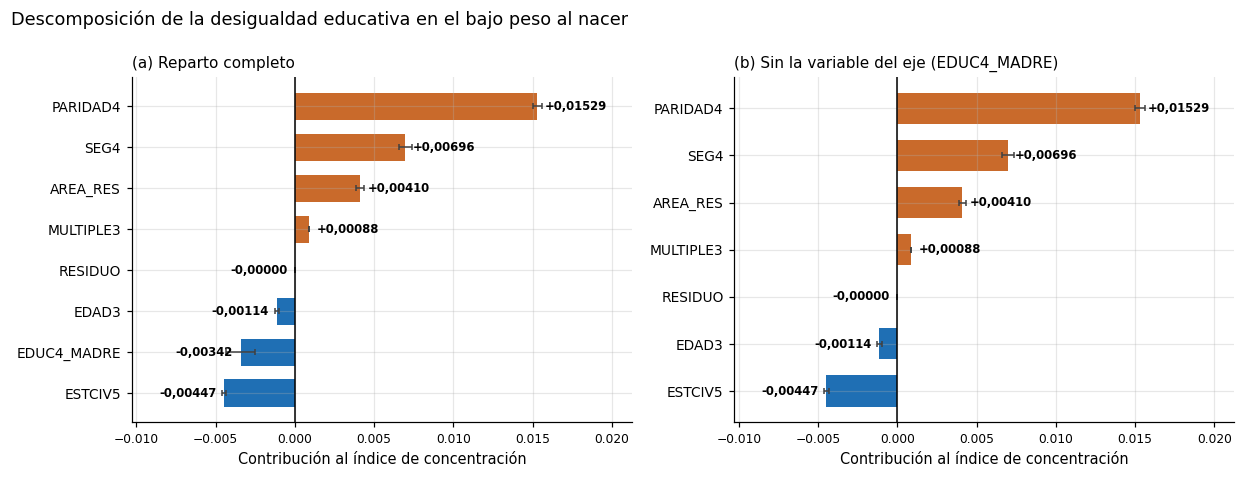

In [7]:
# ---------------------------------------------------------------------------
# Figura: contribuciones ordenadas, en dos paneles
# ---------------------------------------------------------------------------

def _barras(ax, datos, titulo):
    """Dibuja un panel de contribuciones. Se factoriza para no repetir codigo."""
    # Color por signo: la lectura principal de esta figura es la direccion.
    # El residuo va en gris, porque no es un determinante.
    colores = np.where(datos["contribucion"] >= 0, "#c96a2b", "#1f6fb4")
    colores = np.where(datos["variable"] == "RESIDUO", "0.65", colores)

    y = np.arange(len(datos))
    ax.barh(y, datos["contribucion"], color=colores, height=0.66)

    # Barras de error solo donde hay intervalo (el residuo no lo tiene).
    tiene = datos["ic_inf"].notna().to_numpy()
    if tiene.any():
        ax.errorbar(
            datos["contribucion"][tiene], y[tiene],
            xerr=[(datos["contribucion"] - datos["ic_inf"])[tiene],
                  (datos["ic_sup"] - datos["contribucion"])[tiene]],
            fmt="none", ecolor="0.25", elinewidth=1.0, capsize=2.2)

    ax.axvline(0, color="black", lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels(datos["variable"], fontsize=9)
    ax.set_xlabel("Contribución al índice de concentración", fontsize=9.5)
    ax.set_title(titulo, fontsize=10, loc="left")
    ax.tick_params(axis="x", labelsize=8)

    # Valor numerico junto a cada barra, para que la figura se lea sin la tabla.
    # Se coloca SIEMPRE al lado del extremo de la barra, no en una posicion
    # fija: con magnitudes que difieren en dos ordenes, una posicion fija deja
    # las etiquetas de las barras pequenas flotando lejos de su barra.
    for yi, v in zip(y, datos["contribucion"]):
        ax.annotate(f"{v:+.5f}".replace(".", ","), xy=(v, yi),
                    xytext=(5 if v >= 0 else -5, 0), textcoords="offset points",
                    va="center", ha="left" if v >= 0 else "right",
                    fontsize=7.6, fontweight="bold")
    ax.margins(x=0.28)


completo = (con_ic[(con_ic["categoria"] == "TOTAL de la variable") |
                   (con_ic["variable"] == "RESIDUO")]
            .copy().sort_values("contribucion"))

# El panel derecho excluye la variable que ocupa el eje socioeconomico.
sin_eje = completo[completo["variable"] != "EDUC4_MADRE"].copy()

fig, (izq, der) = plt.subplots(1, 2, figsize=(11.4, 4.4))
_barras(izq, completo, "(a) Reparto completo")
_barras(der, sin_eje, "(b) Sin la variable del eje (EDUC4_MADRE)")

fig.suptitle("Descomposición de la desigualdad educativa en el bajo peso al nacer",
             fontsize=11.5, x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.94])
guardar_figura(fig, "fig_descomposicion_contribuciones")
plt.show()

**Cómo se lee esta figura.**

Cada barra es la contribución de un determinante al índice de concentración. Las naranjas
empujan en el mismo sentido que la desigualdad total y las azules la contrarrestan; la gris
es el residuo. Las barras de error son los intervalos bootstrap del bloque 5.

**El panel (a)** da la magnitud real. Que `EDUC4_MADRE` domine no es un hallazgo: es la
identidad algebraica del bloque 3, y así debe presentarse.

**El panel (b)** es donde está la información sustantiva, porque compara entre sí a los
determinantes que no ocupan el eje. Aquí sí tiene sentido preguntarse cuál contribuye más.

La longitud de la barra es lo que se interpreta. Un determinante con barra corta no es
irrelevante para el bajo peso al nacer: es irrelevante *para la desigualdad*, que es otra
cosa. La multiplicidad del embarazo es el caso esperable —factor de riesgo fuerte, barra
corta— y conviene explicarlo en el manuscrito antes de que lo pregunte el jurado.

**Correspondencia con el manuscrito.** Figura de la Sección 5.5.1.

## 7. Robustez: el mismo reparto con otro ordenamiento

**Qué hacemos.** Repetimos la descomposición ordenando la población por **régimen de
afiliación** en lugar de por nivel educativo.

**Por qué.** La Fase 6 ya mostró que el índice de concentración se comporta de forma distinta
según cuál de las dos variables ordene: el educativo cruza el cero en 2019 y el de
aseguramiento no. Queda por saber si el **reparto** entre determinantes también depende de
esa elección. Si los dos ordenamientos atribuyen la mayor contribución a los mismos
determinantes, el resultado es del fenómeno; si no, es en parte del instrumento, y hay que
declararlo.

**Qué cambia en la especificación.** El ordenamiento pasa a ser `SEGORD3` y la educación
vuelve a ser un determinante como los demás. Nótese que ahora es `SEGORD3` la variable cuyo
residuo se anula por construcción: el argumento del bloque 3 se aplica a cualquiera que ocupe
el eje.

In [8]:
# ---------------------------------------------------------------------------
# Robustez: ordenamiento por regimen de afiliacion
# ---------------------------------------------------------------------------

# SEGORD3 es la escala ordinal de tres niveles que construyo la Fase 1b. Se usa
# esta y no SEG4 porque el indice de concentracion exige un ORDEN, y "especial
# o excepcion" no tiene posicion definida en una jerarquia socioeconomica.
DETERMINANTES_SEG = (["SEGORD3", "EDUC4_MADRE", "ESTCIV5", "AREA_RES"]
                     + DEMOGRAFICAS)

with cronometro("descomposicion con ordenamiento por aseguramiento"):
    tabla_seg, resumen_seg = descomposicion.descomponer(
        muestra, orden="SEGORD3", variables=DETERMINANTES_SEG,
        referencias=REFERENCIAS)

tot_seg = (tabla_seg[tabla_seg["categoria"] == "TOTAL de la variable"]
           [["variable", "contribucion", "pct_del_total"]]
           .rename(columns={"contribucion": "contrib_seg",
                            "pct_del_total": "pct_seg"}))
tot_edu = (totales[["variable", "contribucion", "pct_del_total"]]
           .rename(columns={"contribucion": "contrib_edu",
                            "pct_del_total": "pct_edu"}))

lado_a_lado = tot_edu.merge(tot_seg, on="variable", how="outer")
# Se ordena por la magnitud del reparto educativo, que es el principal.
lado_a_lado = lado_a_lado.sort_values("pct_edu", key=abs, ascending=False)

print(f"ordenamiento educativo     CI = {resumen['ci']:.6f}")
print(f"ordenamiento aseguramiento CI = {resumen_seg['ci']:.6f}\n")
print("REPARTO SEGUN EL ORDENAMIENTO (porcentaje del indice de cada uno)\n")
print(lado_a_lado.to_string(index=False))

guardar_tabla(lado_a_lado, "descomposicion_dos_ordenamientos", decimales=6)

[inicio] descomposicion con ordenamiento por aseguramiento
[fin]    descomposicion con ordenamiento por aseguramiento  ->  9.1 s
ordenamiento educativo     CI = 0.018182
ordenamiento aseguramiento CI = 0.024226

REPARTO SEGUN EL ORDENAMIENTO (porcentaje del indice de cada uno)

   variable  contrib_edu    pct_edu  contrib_seg    pct_seg
   PARIDAD4     0.015289  84.089974     0.006387  26.362925
       SEG4     0.006955  38.253252          NaN        NaN
    ESTCIV5    -0.004473 -24.600604    -0.006382 -26.341559
   AREA_RES     0.004096  22.526674     0.003629  14.978729
EDUC4_MADRE    -0.003425 -18.837276    -0.001759  -7.262687
      EDAD3    -0.001143  -6.285388     0.002069   8.538443
  MULTIPLE3     0.000882   4.853367     0.003616  14.924276
    SEGORD3          NaN        NaN     0.016668  68.799873
tabla guardada: descomposicion_dos_ordenamientos.csv y descomposicion_dos_ordenamientos.tex


**Cómo se lee esta salida.**

Los dos índices totales **no** tienen por qué coincidir: son dos cantidades distintas, la
desigualdad a lo largo del gradiente educativo y a lo largo del de aseguramiento. Lo
comparable son los porcentajes, no los valores absolutos.

Lo que hay que buscar es si el **ordenamiento de los determinantes** se conserva. Si en las
dos columnas los mismos dos o tres determinantes encabezan el reparto, la conclusión del
objetivo 4 es robusta a la elección del eje socioeconómico y así puede enunciarse. Si el
orden se altera, el manuscrito debe decir que el reparto depende de cómo se defina la
posición social, que es una limitación real y no un defecto del análisis.

Obsérvese que en cada columna la variable que ocupa el eje absorbe el residuo por
construcción, de modo que su porcentaje no es comparable con el de la otra columna. Los
comparables son los determinantes que no ocupan el eje en ninguna de las dos.

**Correspondencia con el manuscrito.** Alimenta la Sección 5.7, junto con el resto del
análisis de sensibilidad.

## 8. Descomposición por subperíodo

**Qué hacemos.** Repetimos la descomposición en tres tramos de la serie y comparamos el
reparto entre ellos.

**Por qué hace falta, y es la objeción más seria a los bloques anteriores.** La Fase 3
estableció que el índice de concentración **cambia de signo en 2019**: hasta entonces el bajo
peso al nacer se concentra en el extremo más educado y a partir de ahí en el menos educado.
Una descomposición del período completo promedia esos dos regímenes opuestos en una sola
cifra, y el resultado no describe bien a ninguno de los dos. Peor: el reparto podría estar
dominado por el tramo con más nacimientos y no por el que interesa.

Los tres tramos siguen la forma de la serie anual:

| Tramo | Qué ocurre en el índice |
|---|---|
| **1998–2009** | asciende hasta el máximo de $+0{,}00726$ |
| **2010–2018** | desciende de forma sostenida hacia el cero |
| **2019–2024** | negativo los seis años, hasta $-0{,}00651$ |

**Qué pregunta responde este bloque.** Si los mismos determinantes mandan en los tres tramos,
la inversión es un cambio de intensidad y el mecanismo es estable. Si el reparto se reordena
—por ejemplo, si un determinante cambia de signo—, entonces la inversión tiene una explicación
composicional concreta y puede nombrarse, que es mucho más de lo que se puede decir hoy.

**Una advertencia sobre los tamaños.** Los tres tramos no tienen el mismo número de
nacimientos, de modo que los porcentajes son comparables entre sí pero las contribuciones
absolutas hay que leerlas junto al índice total de cada tramo, que también se reporta.

In [9]:
# ---------------------------------------------------------------------------
# Descomposicion por subperiodo
# ---------------------------------------------------------------------------

# Los cortes siguen la forma de la serie anual de la Fase 3: ascenso, descenso
# y tramo negativo. No son arbitrarios ni estan elegidos para que salga algo:
# el corte de 2019 es el anio en que el indice cruza el cero, y el de 2009 el
# del maximo.
TRAMOS = {
    "1998-2009 (ascenso)":  (1998, 2009),
    "2010-2018 (descenso)": (2010, 2018),
    "2019-2024 (negativo)": (2019, 2024),
}

resumenes, repartos, porcentajes = {}, {}, {}

for nombre, (a1, a2) in TRAMOS.items():
    sub = muestra[(muestra["ANIO"] >= a1) & (muestra["ANIO"] <= a2)]
    with cronometro(f"descomposicion {nombre}"):
        t, r = descomposicion.descomponer(
            sub, orden="EDUC4_MADRE", variables=DETERMINANTES,
            referencias=REFERENCIAS)
    resumenes[nombre] = r
    # Solo los totales por variable: no dependen de cual sea la categoria de
    # referencia, de modo que son lo comparable entre tramos.
    tot = t[t["categoria"] == "TOTAL de la variable"].set_index("variable")
    repartos[nombre] = tot["contribucion"]
    porcentajes[nombre] = tot["pct_del_total"]

# --- Indice de cada tramo --------------------------------------------------
cabecera = pd.DataFrame({
    "tramo": list(resumenes),
    "n": [r["n"] for r in resumenes.values()],
    "prevalencia_pct": [r["prevalencia_global"] * 100 for r in resumenes.values()],
    "ci": [r["ci"] for r in resumenes.values()],
    "erreygers": [r["erreygers"] for r in resumenes.values()],
})

print("EL INDICE EN CADA TRAMO\n")
print(cabecera.round(6).to_string(index=False))

# --- Reparto lado a lado ---------------------------------------------------
#
# SE COMPARAN LAS CONTRIBUCIONES ABSOLUTAS, NO LOS PORCENTAJES.
#
# POR QUE, y es la decision que hace utilizable este bloque: el porcentaje se
# calcula dividiendo por el indice del tramo, y en el tramo 2019-2024 ese
# indice esta cerca de cero. Dividir por una cantidad pequena infla los
# porcentajes hasta hacerlos incomparables —aparecen valores de varios cientos
# por ciento que no significan que ese determinante importe mas, sino que el
# denominador es diminuto—. Las contribuciones absolutas estan todas en la
# misma escala, la del indice, y suman exactamente el indice de su tramo.
#
# Los porcentajes se conservan en una tabla aparte porque siguen siendo la
# forma natural de leer UN tramo por separado. Lo que no admiten es comparar
# entre tramos.
lado = pd.DataFrame(repartos)
lado = lado.reindex(lado.abs().max(axis=1).sort_values(ascending=False).index)

print("\n\nCONTRIBUCION POR TRAMO  (absoluta; suma = indice del tramo)\n")
print(lado.round(6).to_string())

# Comprobacion: la suma de contribuciones de cada tramo debe reproducir su
# indice. Si no cuadra, algo se perdio al reagrupar.
suma = lado.sum()
ci_tramo = cabecera.set_index("tramo")["ci"]
print("\ncomprobacion  suma de contribuciones = indice del tramo:")
for t in lado.columns:
    ok = np.isclose(suma[t], ci_tramo[t])
    print(f"  {t:<24} {suma[t]:>10.6f}  vs  {ci_tramo[t]:>10.6f}   "
          f"{'OK' if ok else 'NO CUADRA'}")

pct = pd.DataFrame(porcentajes).reindex(lado.index)
print("\n\nLos mismos numeros en % del indice de su tramo\n")
print(pct.round(1).to_string())
print("\nNOTA: en el tramo 2019-2024 el indice esta cerca de cero, de modo que")
print("estos porcentajes se disparan. Sirven para leer ese tramo por separado,")
print("NO para compararlo con los otros dos.")

guardar_tabla(cabecera, "descomposicion_tramos_indice", decimales=6)
guardar_tabla(lado.reset_index(), "descomposicion_tramos_reparto", decimales=6)
guardar_tabla(pct.reset_index(), "descomposicion_tramos_porcentaje", decimales=2)

[inicio] descomposicion 1998-2009 (ascenso)
[fin]    descomposicion 1998-2009 (ascenso)  ->  4.5 s
[inicio] descomposicion 2010-2018 (descenso)
[fin]    descomposicion 2010-2018 (descenso)  ->  3.1 s
[inicio] descomposicion 2019-2024 (negativo)
[fin]    descomposicion 2019-2024 (negativo)  ->  1.8 s
EL INDICE EN CADA TRAMO

               tramo       n  prevalencia_pct        ci  erreygers
 1998-2009 (ascenso) 7108037         8.079812  0.016824   0.005437
2010-2018 (descenso) 5618393         8.926894  0.010518   0.003756
2019-2024 (negativo) 3219786        10.002932 -0.003848  -0.001540


CONTRIBUCION POR TRAMO  (absoluta; suma = indice del tramo)

             1998-2009 (ascenso)  2010-2018 (descenso)  2019-2024 (negativo)
variable                                                                    
EDUC4_MADRE            -0.007206             -0.015042             -0.029918
PARIDAD4                0.016605              0.012925              0.010962
SEG4                    0.006091   

**Cómo se lee esta salida.**

La tabla de cabecera confirma que los tres tramos son lo que dicen ser: el índice debe salir
claramente positivo en el primero y negativo en el tercero. Si no fuera así, el corte estaría
mal hecho y el resto del bloque no significaría nada.

**Por qué se comparan contribuciones absolutas y no porcentajes.** El porcentaje divide por el
índice del tramo, y en 2019–2024 ese índice está cerca de cero. Dividir por una cantidad
diminuta infla los porcentajes hasta valores de varios cientos, que no indican que el
determinante pese más sino que el denominador es pequeño. Las contribuciones absolutas están
todas en la misma escala y suman exactamente el índice de su tramo, que es lo que comprueba la
línea de verificación.

En la tabla, lo que hay que buscar es doble:

- **Un determinante que cambie de signo** entre el primer tramo y el tercero. Significa que su
  relación con el gradiente educativo se dio la vuelta, y es candidato a explicar la inversión.
- **Un determinante cuya contribución crezca mucho en magnitud sin cambiar de signo.** Si
  crece en la dirección contraria al índice inicial, arrastra el total hacia el cero y luego lo
  cruza. Esta segunda vía es la que suele pasarse por alto, y explica una inversión igual de
  bien que la primera.

**Lo que este bloque no puede resolver.** Los tramos son tramos de tiempo, de modo que
cualquier cambio que coincida con ellos —el fenómeno, la cobertura del registro o la versión
del instrumento— queda confundido. Este bloque dice *qué* se reordena, no *por qué*.

**Correspondencia con el manuscrito.** Sección 5.5.3, y alimenta la discusión sobre la
inversión del gradiente de la Sección 5.3.4.

figura guardada: fig_descomposicion_tramos.pdf y fig_descomposicion_tramos.png


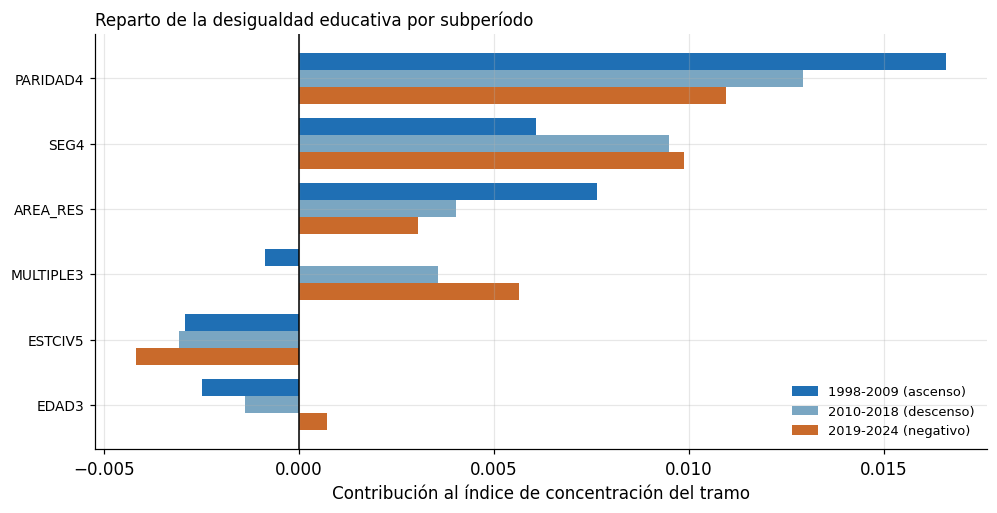

In [10]:
# ---------------------------------------------------------------------------
# Figura: como se reordena el reparto entre tramos
# ---------------------------------------------------------------------------

# Se excluye la variable del eje: absorbe el residuo por construccion y su
# barra no es comparable con las demas (bloque 3).
para_fig = lado.drop(index="EDUC4_MADRE", errors="ignore")

fig, ax = plt.subplots(figsize=(9.2, 4.8))

variables = list(para_fig.index)
y = np.arange(len(variables))
alto = 0.26
paleta = ["#1f6fb4", "#7aa6c2", "#c96a2b"]

for k, (tramo, color) in enumerate(zip(para_fig.columns, paleta)):
    ax.barh(y + (k - 1) * alto, para_fig[tramo], height=alto,
            color=color, label=tramo)

ax.axvline(0, color="black", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(variables, fontsize=9)
ax.set_xlabel("Contribución al índice de concentración del tramo")
ax.set_title("Reparto de la desigualdad educativa por subperíodo",
             fontsize=11, loc="left")
ax.legend(fontsize=8.5, loc="lower right")
ax.invert_yaxis()   # el mayor arriba, como en la tabla

guardar_figura(fig, "fig_descomposicion_tramos")
plt.show()

**Cómo se lee esta figura.**

Cada grupo de tres barras es un determinante; cada barra, un tramo de la serie. La escala es
el porcentaje del índice **de su propio tramo**, de modo que barras de distinto tramo son
comparables aunque los índices totales difieran en magnitud y en signo.

Lo que la figura hace visible de un vistazo, y la tabla no: si las tres barras de un
determinante apuntan al mismo lado, su papel es estable; si una apunta al contrario, ahí está
el reordenamiento.

La variable del eje socioeconómico se omite por la razón del bloque 3: absorbe el residuo por
construcción y su barra no es comparable con las demás.

**Correspondencia con el manuscrito.** Figura de la Sección 5.5.3.

## 9. Cierre

**Qué queda escrito en disco.**

| Archivo | Contenido | Sección |
|---|---|---|
| `descomposicion_por_variable` | contribución de cada determinante | 5.5.1 |
| `descomposicion_componentes` | elasticidad y $CI_k$ por categoría | 5.5.2 |
| `descomposicion_con_intervalos` | todo, con intervalos bootstrap | 5.5.1 |
| `descomposicion_residuo_cero` | la comprobación del bloque 3 | 4.4.5 |
| `descomposicion_dos_ordenamientos` | robustez al eje socioeconómico | 5.7 |
| `fig_descomposicion_contribuciones` | la figura | 5.5.1 |
| `descomposicion_tramos_indice` | el índice en cada subperíodo | 5.5.3 |
| `descomposicion_tramos_reparto` | reparto por subperíodo | 5.5.3 |
| `fig_descomposicion_tramos` | la figura por subperíodo | 5.5.3 |

**Las tres cosas que esta fase deja establecidas.**

1. Qué proporción de la brecha socioeconómica es atribuible a cada determinante, que es el
   objetivo específico 4.
2. La separación de cada contribución en efecto y desigualdad de la exposición, que es lo que
   distingue un problema de riesgo de un problema de distribución.
3. Que el residuo nulo es una identidad algebraica y no un logro del modelo, declarado antes
   de que nadie lo pregunte.
4. Si el reparto entre determinantes es estable a lo largo del período o se reordena cuando
   el índice cambia de signo, que es la pregunta que deja abierta la Sección 5.3.4.

**Lo que no puede afirmarse a partir de aquí.** Que un determinante con contribución alta
*cause* esa parte de la desigualdad. La descomposición es contable, no causal: reparte una
cantidad observada según una asociación estimada. La estimación de efectos ajustados por
confusión es la Fase 4, y las dos lecturas se contrastan en la discusión.

In [11]:
# ---------------------------------------------------------------------------
# Inventario de lo generado
# ---------------------------------------------------------------------------

from config import DIR_FIGURAS

print("TABLAS\n")
for n in ["descomposicion_por_variable", "descomposicion_componentes",
          "descomposicion_con_intervalos", "descomposicion_residuo_cero",
          "descomposicion_dos_ordenamientos",
          "descomposicion_tramos_indice",
          "descomposicion_tramos_reparto"]:
    for ext in ("csv", "tex"):
        ruta = DIR_TABLAS / f"{n}.{ext}"
        print(f"  {'OK ' if ruta.exists() else 'FALTA'}  {ruta.name}")

print("\nFIGURAS\n")
for nombre in ["fig_descomposicion_contribuciones", "fig_descomposicion_tramos"]:
    for ext in ("pdf", "png"):
        ruta = DIR_FIGURAS / f"{nombre}.{ext}"
        print(f"  {'OK ' if ruta.exists() else 'FALTA'}  {ruta.name}")

print("\nFase 5 terminada.")

TABLAS

  OK   descomposicion_por_variable.csv
  OK   descomposicion_por_variable.tex
  OK   descomposicion_componentes.csv
  OK   descomposicion_componentes.tex
  OK   descomposicion_con_intervalos.csv
  OK   descomposicion_con_intervalos.tex
  OK   descomposicion_residuo_cero.csv
  OK   descomposicion_residuo_cero.tex
  OK   descomposicion_dos_ordenamientos.csv
  OK   descomposicion_dos_ordenamientos.tex
  OK   descomposicion_tramos_indice.csv
  OK   descomposicion_tramos_indice.tex
  OK   descomposicion_tramos_reparto.csv
  OK   descomposicion_tramos_reparto.tex

FIGURAS

  OK   fig_descomposicion_contribuciones.pdf
  OK   fig_descomposicion_contribuciones.png
  OK   fig_descomposicion_tramos.pdf
  OK   fig_descomposicion_tramos.png

Fase 5 terminada.
